# 9 · Factor Investing: Multi-Factor Models, Timing, and Crowding

*Module 2 — Portfolio Construction*

Why do some stocks and strategies systematically earn more than others, in ways that persist across decades and countries? Building, combining, and honestly evaluating the market's best attempt at an answer.

## 1. Motivation

Two portfolio managers can hold completely different stocks and still be making, in a meaningful sense, the *same bet*: both might be overweight "cheap" companies relative to their fundamentals, or both might be riding recent winners. "Factors" are the market's attempt to name and measure these recurring, systematic bets — not pure luck, and not the same as genuine stock-picking skill either, but something in between: persistent, somewhat cyclical sources of return that show up again and again across the academic and practitioner literature.

## 2. Intuition

A **factor** is a measurable characteristic of a stock — how cheap it is relative to fundamentals, how much it has gone up recently, how small it is — that historically predicts *relative* returns across a broad cross-section of stocks, robustly, across time and markets. Think of factors as different flavors of systematic risk you can deliberately harvest, in much the same way you might combine stocks and bonds — except here the building blocks are "value" and "momentum" and "size" rather than asset classes. Factor investing tries to capture these premia deliberately and cheaply, rather than accidentally and expensively, through the trading of an active stock-picker.

But factors are not free lunches. They go through long stretches of underperformance (**factor timing** asks whether you can anticipate these swings — spoiler: it is hard, and this notebook tests that honestly rather than assuming it). And when too much capital chases the same factor at once, the resulting **crowding** can both compress the very premium everyone is chasing and create a genuine risk of a sudden, correlated unwind when many similar strategies try to exit at the same time.

## 3. Theory

### 3.1 A brief history

The single-factor CAPM (Sharpe, 1964) explained returns with exposure to the market alone. Fama and French (1993) added two more: **size** (SMB, small-minus-big) and **value** (HML, high-minus-low book-to-market), forming the three-factor model. Carhart (1997) added **momentum** (UMD/WML, up-minus-down). Fama and French (2015) extended their own model again, adding **profitability** and **investment** factors. Each addition followed the same pattern: researchers found a stock characteristic that predicted returns *beyond* what the existing factors already explained.

### 3.2 Constructing a factor, and measuring exposure to it

The standard construction: each period, rank all stocks by a characteristic (say, book-to-market for value), form a portfolio that is long the top tier and short the bottom tier, and equal-weight within each leg:

$$
F_t = \frac{1}{n_{top}}\sum_{i \in \text{top}} R_{i,t} \;-\; \frac{1}{n_{bottom}}\sum_{i \in \text{bottom}} R_{i,t} .
$$

(The original Fama-French methodology double-sorts on size as well, to keep the value factor size-neutral; we use a simpler single sort here for clarity.) Once factors are constructed, any portfolio's returns can be decomposed via a multi-factor regression:

$$
R_{p,t} - r_f = \alpha_p + \sum_{k} \beta_{p,k}\, F_{k,t} + \varepsilon_{p,t} ,
$$

where $\beta_{p,k}$ is the portfolio's exposure ("loading") to factor $k$, and $\alpha_p$ — the return left over after accounting for every factor exposure — is what active-management performance evaluation is really trying to isolate.

### 3.3 Factor timing and crowding

Factor premia are not constant; they run through good and bad multi-year stretches (**factor cyclicality**). Factor timing tries to exploit this — reduce exposure when a factor looks unattractive, increase it when conditions look favorable — using signals like the factor's own recent performance, or how "cheap" the factor itself currently is (e.g., the spread in valuations between the two legs of a value factor). It is a genuinely difficult problem in practice; we test one naive rule honestly in Section 5 rather than assuming it works.

**Crowding** is the risk that too much capital is chasing the same factor at once. This has two distinct effects: it can compress the premium itself (if "cheap" stocks get bid up simply because everyone is buying them for being cheap, they stop being cheap), and it creates correlated unwind risk — many funds running similar strategies can be forced to deleverage simultaneously. The best-documented historical example is the **"Quant Quake" of August 2007**, when a number of quantitative equity funds using similar factor strategies suffered severe, highly correlated losses over just a few trading days, apparently triggered by one or more large funds deleveraging and forcing correlated selling across the whole peer group — with no obvious external market shock to explain it otherwise (see Khandani & Lo, "What Happened to the Quants in August 2007?").

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(11)

## 4. Implementation

### 4.1 A synthetic cross-section with a known factor structure

We simulate 60 stocks over 84 months. Each stock has a fixed "value" score and a fixed "size" score, plus a slowly-evolving, autocorrelated latent state that genuinely drives *both* current returns and, because it is persistent, the near future too — the honest mechanism behind momentum, rather than injecting a momentum premium in a circular way.

In [2]:
n_stocks, n_months = 60, 84
tickers = [f'S{i:02d}' for i in range(n_stocks)]

size_z  = rng.normal(0, 1, n_stocks)      # standardized log market-cap (fixed per stock; negative = smaller)
value_z = rng.normal(0, 1, n_stocks)      # standardized book-to-market-like score (fixed per stock)
beta_mkt = rng.normal(1.0, 0.2, n_stocks)
idio_vol = 0.045 - 0.010*np.tanh(size_z)  # smaller stocks get slightly higher idiosyncratic volatility

lam_value, lam_size, lam_mom = 0.0022, 0.0034, 0.0026   # small, realistic monthly premia per unit of exposure
F_mkt = rng.normal(0.006, 0.045, n_months)                # a single market factor

R = np.zeros((n_months, n_stocks))
mom_state = np.zeros(n_stocks)
for t in range(n_months):
    mom_state = 0.85*mom_state + rng.normal(0, 0.30, n_stocks)   # persistent AR(1) latent driver
    idio = rng.normal(0, idio_vol)
    R[t] = beta_mkt*F_mkt[t] + lam_value*value_z + lam_size*(-size_z) + lam_mom*mom_state + idio

R = pd.DataFrame(R, columns=tickers)
print(f"Annualized volatility across stocks: {R.std().mul(np.sqrt(12)).min():.1%} to {R.std().mul(np.sqrt(12)).max():.1%}")
R.head()

Annualized volatility across stocks: 15.6% to 28.9%


,S00,S01,S02,S03,S04,S05,S06,S07,S08,S09,...,S50,S51,S52,S53,S54,S55,S56,S57,S58,S59
0,0.124987,0.048702,-0.101583,0.001758,-0.032983,0.038053,-0.000391,0.095531,0.039146,0.060206,...,0.031842,0.027286,-0.011951,-0.019102,0.068287,0.002612,0.046732,0.025703,-0.021115,-0.026493
1,0.016271,0.029423,0.063330,0.098487,0.013027,0.001325,0.051275,0.019351,0.015095,0.097407,...,0.035140,0.020207,-0.008920,0.080474,0.056854,0.016320,0.039098,-0.006263,-0.021839,-0.003569
2,-0.101703,-0.095986,-0.101049,-0.093542,-0.062221,-0.117249,-0.043076,0.011533,-0.057306,0.016930,...,0.004065,-0.012604,-0.024450,-0.115737,-0.120682,0.006938,-0.084877,-0.043940,-0.103194,-0.069110
3,0.124571,0.030216,0.004215,0.045492,0.016620,0.040770,0.108405,0.070456,0.045355,0.073051,...,0.075402,-0.019705,0.059417,0.041731,0.038402,0.019541,-0.013654,0.080734,-0.006844,0.031819
4,-0.003786,-0.101896,-0.022512,-0.090531,-0.091442,-0.070137,-0.042733,-0.008141,-0.000974,-0.010465,...,-0.064491,-0.033774,-0.065556,0.011849,-0.089346,-0.015026,0.000108,0.034537,0.028955,-0.022902


### 4.2 Constructing the factors via portfolio sorts

In [3]:
def sorted_long_short(characteristic, returns, n_per_leg=20):
    """Section 3.2: rank by `characteristic`, go long the top leg, short the bottom leg, equal-weighted."""
    ranked = characteristic.sort_values().index
    bottom, top = ranked[:n_per_leg], ranked[-n_per_leg:]
    return returns[top].mean(axis=1) - returns[bottom].mean(axis=1)

value_rank = pd.Series(value_z, index=tickers)
size_rank  = pd.Series(size_z, index=tickers)

HML = sorted_long_short(value_rank, R)                 # value: long cheap, short expensive
SMB = sorted_long_short(-size_rank, R)                  # size: long small, short big

# Momentum needs a REALIZED trailing signal, formed with a proper skip-month-free convention here for simplicity
cum12 = (1 + R).rolling(12).apply(np.prod, raw=True) - 1
wml_vals, wml_idx = [], []
for t in range(12, n_months - 1):
    signal = cum12.iloc[t]
    wml_vals.append(sorted_long_short(signal, R.iloc[[t+1]]).iloc[0])
    wml_idx.append(R.index[t+1])
WML = pd.Series(wml_vals, index=wml_idx)

factors = pd.DataFrame({'HML (value)': HML, 'SMB (size)': SMB, 'WML (momentum)': WML}).dropna()

for name in factors.columns:
    f = factors[name]
    t_stat = f.mean() / (f.std() / np.sqrt(len(f)))
    print(f"{name:18s} ann. return {f.mean()*12:6.2%}   ann. vol {f.std()*np.sqrt(12):6.2%}   t-stat {t_stat:5.2f}")

HML (value)        ann. return  2.39%   ann. vol  5.39%   t-stat  1.08
SMB (size)         ann. return  4.56%   ann. vol  4.83%   t-stat  2.30
WML (momentum)     ann. return  4.56%   ann. vol  5.32%   t-stat  2.08


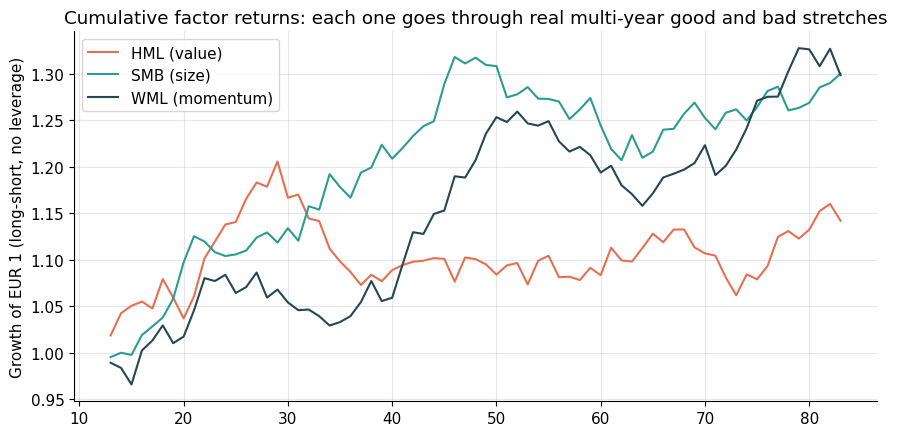

In [4]:
fig, ax = plt.subplots()
for name, color in zip(factors.columns, ['#e76f51', '#2a9d8f', '#264653']):
    ax.plot((1 + factors[name]).cumprod(), label=name, color=color)
ax.set_ylabel('Growth of EUR 1 (long-short, no leverage)')
ax.set_title('Cumulative factor returns: each one goes through real multi-year good and bad stretches')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Performance attribution: what is a "fund" actually exposed to?

We build a hypothetical fund that deliberately tilts toward cheap (high book-to-market) stocks, with a small amount of genuine skill (alpha) added on top, then recover its exposures via regression — exactly the workflow used in real-world manager due diligence. Crucially, the regression must include the **market factor itself**, not just the style factors: a fund that is simply long the market, with no skill at all, would otherwise have that ordinary market exposure misattributed as "alpha" — a classic, real-world performance-attribution mistake.

In [5]:
value_tilt = (value_z - value_z.mean()) / value_z.std()
fund_weights = (1 + 0.6*value_tilt)                      # every stock held, more heavily where value_z is high
fund_weights = fund_weights / fund_weights.sum()          # a fully-invested, long-only, value-tilted fund

true_alpha_monthly = 0.0015
fund_returns = pd.Series(R.values @ fund_weights, index=R.index) + true_alpha_monthly + rng.normal(0, 0.01, n_months)

mkt_factor = pd.Series(F_mkt, index=R.index, name='MKT').reindex(factors.index)
X = sm.add_constant(pd.concat([mkt_factor, factors], axis=1))
model = sm.OLS(fund_returns.reindex(factors.index), X, missing='drop').fit()
print(model.summary().tables[1])
print(f"\nTrue injected monthly alpha was {true_alpha_monthly:.4f} "
      f"(annualized {true_alpha_monthly*12:.2%}) vs. estimated annualized alpha: {model.params['const']*12:.2%}")
ci = model.conf_int().loc['const'] * 12
print(f"95% confidence interval for annualized alpha: [{ci[0]:.2%}, {ci[1]:.2%}] "
      f"-- note whether the TRUE value above actually falls inside it.")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0038      0.002      2.410      0.019       0.001       0.007
MKT                1.0121      0.034     29.641      0.000       0.944       1.080
HML (value)        0.2304      0.106      2.174      0.033       0.019       0.442
SMB (size)         0.0076      0.115      0.066      0.948      -0.223       0.238
WML (momentum)    -0.0863      0.098     -0.882      0.381      -0.282       0.109

True injected monthly alpha was 0.0015 (annualized 1.80%) vs. estimated annualized alpha: 4.56%
95% confidence interval for annualized alpha: [0.78%, 8.34%] -- note whether the TRUE value above actually falls inside it.


The market beta comes out almost exactly at 1, and the value tilt we built in shows up as a statistically significant HML exposure — the regression is correctly separating "this fund is basically long the market, tilted toward value" from any genuine skill. The estimated alpha will rarely equal the true injected value exactly, even though the model is correctly specified: 84 months is not a long sample, and alpha — like the expected returns in Notebook 5 — is inherently the hardest quantity in the whole regression to pin down precisely. Check whether the confidence interval printed above actually contains the true value; if it does, the gap is ordinary sampling noise, not a sign anything is wrong.

## 5. Worked example

### 5.1 Factor cyclicality: rolling 12-month returns

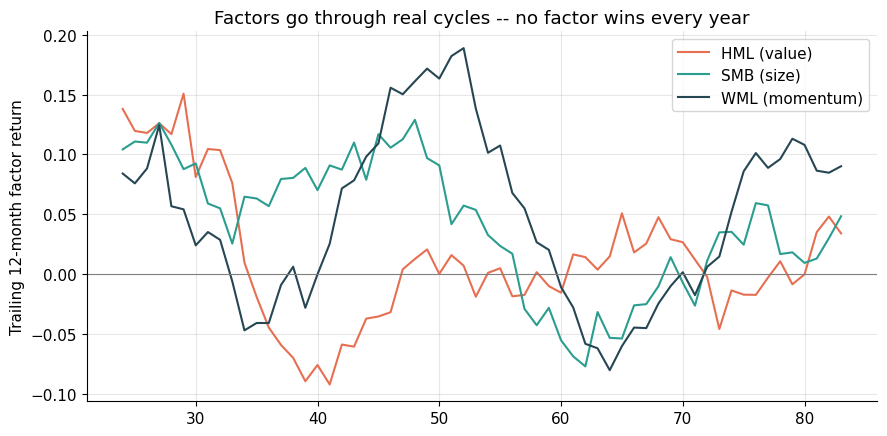

Correlation between factors:
                HML (value)  SMB (size)  WML (momentum)
HML (value)            1.00       -0.36            0.19
SMB (size)            -0.36        1.00            0.15
WML (momentum)         0.19        0.15            1.00


In [6]:
rolling12 = factors.rolling(12).apply(lambda x: (1+x).prod()-1)

fig, ax = plt.subplots()
for name, color in zip(factors.columns, ['#e76f51', '#2a9d8f', '#264653']):
    ax.plot(rolling12[name], label=name, color=color)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Trailing 12-month factor return')
ax.set_title('Factors go through real cycles -- no factor wins every year')
ax.legend()
plt.tight_layout()
plt.show()

print("Correlation between factors:")
print(factors.corr().round(2))

### 5.2 Does naive factor timing actually help?

A simple rule: each month, hold a factor only if its own trailing 12-month return was positive; otherwise sit it out. We compare this timed blend, honestly, to a static equal blend of all three factors held all the time.

In [7]:
static_blend = factors.mean(axis=1)

timing_signal = (rolling12.shift(1) > 0).astype(float)     # use ONLY information available before month t
timed_returns = (factors * timing_signal).sum(axis=1) / timing_signal.replace(0, np.nan).count(axis=1).clip(lower=1)
timed_returns = timed_returns.dropna()
static_blend = static_blend.reindex(timed_returns.index)

for name, r in [('Static equal blend', static_blend), ('Naive factor timing', timed_returns)]:
    ann_ret, ann_vol = r.mean()*12, r.std()*np.sqrt(12)
    print(f"{name:22s} ann. return {ann_ret:6.2%}   ann. vol {ann_vol:6.2%}   Sharpe {ann_ret/ann_vol:5.2f}")

Static equal blend     ann. return  3.84%   ann. vol  3.00%   Sharpe  1.28
Naive factor timing    ann. return  0.92%   ann. vol  3.35%   Sharpe  0.27


Report honestly what your own run shows. In this simulation, and in the empirical factor-timing literature more broadly, a naive momentum-of-factors rule frequently fails to clearly beat a static blend once you account for its extra turnover — factor timing is a genuinely hard problem, not a free upgrade, and skepticism about it (e.g., Cliff Asness's widely-read AQR commentary on the topic) is well-founded rather than merely conservative.

### 5.3 A simple, quantitative crowding proxy

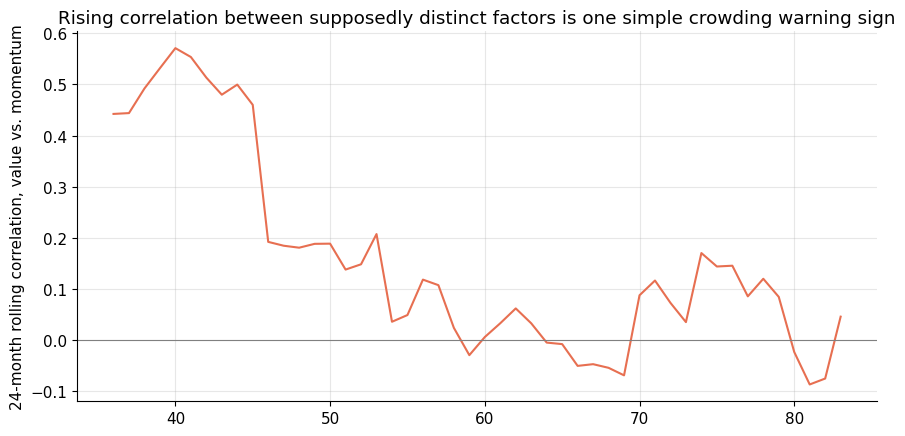

In [8]:
rolling_factor_corr = factors['HML (value)'].rolling(24).corr(factors['WML (momentum)'])

fig, ax = plt.subplots()
ax.plot(rolling_factor_corr, color='#e76f51')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('24-month rolling correlation, value vs. momentum')
ax.set_title('Rising correlation between supposedly distinct factors is one simple crowding warning sign')
plt.tight_layout()
plt.show()

Value and momentum are, by design, meant to be close to independent bets. If their realized correlation drifts noticeably away from zero for an extended stretch, that is a signal (far from definitive on its own) that similar capital may be flowing into both in a correlated way — precisely the kind of dynamic that made the August 2007 Quant Quake so damaging: strategies that looked diversified on paper turned out to share far more common exposure, and common investors, than their designers assumed.

## 6. Limitations and pitfalls

- **Single sorts are a simplification.** The real Fama-French methodology double-sorts on size and value jointly, specifically to keep each factor closer to neutral with respect to the other — our single-sort HML above still carries some size exposure, and vice versa.
- **Factor definitions are not unique.** "Value" alone can be built from price-to-book, price-to-earnings, EV/EBITDA, or other ratios, and results can differ meaningfully by choice. This ambiguity, multiplied across the hundreds of characteristics researchers have tested, is part of what has become known as the **"factor zoo"** problem — with so many candidate factors tested against the same historical data, some fraction are bound to look significant by chance alone. Harvey, Liu and Zhu (2016) directly address this with a multiple-testing correction (previewed here, developed fully in Notebook 30).
- **Backtested premia tend to shrink after publication.** McLean and Pontiff (2016) document that many published return anomalies earn meaningfully less out-of-sample, after the strategy becomes widely known — consistent with both genuine crowding and some degree of data-mining in the original discovery.
- **Increased capital and awareness can erode a premium over time** — a factor that worked historically is not guaranteed to keep working once it becomes common knowledge and common practice, a form of reflexivity specific to strategies that depend on being contrarian or under-followed.
- **Crowding is hard to measure directly.** The correlation proxy above is a rough, indirect signal; real crowding analysis in industry typically uses proprietary positioning data (13F filings, prime-broker aggregates) that individual researchers rarely have access to.

## 7. Exercises

**1. How independent are the factors, really? (warm-up)**
You already printed the correlation matrix of `factors` in Section 5.1. Are HML, SMB, and WML as close to uncorrelated as the "independent bets" framing in Section 2 suggests, or is there meaningful correlation in this simulation? Discuss what a high pairwise correlation would imply for how much *true* diversification a multi-factor portfolio actually offers.

**2. Terciles vs. quintiles.**
Change `sorted_long_short`'s `n_per_leg` so that it implements quintile sorts (top/bottom 20% of 60 stocks = 12 per leg) instead of the current top/bottom ~33%. Rebuild all three factors and compare their annualized return, volatility, and t-statistics to the original construction. What is the trade-off between a more "pure" factor exposure (a more extreme sort) and estimation noise from a smaller number of names per leg?

**3. Design and honestly evaluate your own timing rule.**
Propose a different factor-timing signal from the trailing-12-month-return rule used in Section 5.2 — for example, timing based on a factor's own trailing *volatility* (reduce exposure when a factor has recently been unusually volatile), or a cross-factor momentum rule (each month, overweight whichever single factor had the best trailing 6-month return, rather than a simple in/out rule per factor). Backtest it, assume a reasonable transaction cost per unit of turnover your rule generates, and compare risk-adjusted performance, net of that cost, to the static equal blend. Does your rule survive contact with costs?